<a href="https://colab.research.google.com/github/hycienti/Probability-Distributions-Bayesian-Probability-and-Gradient-Descent-Implementation/blob/part4/Probability_Distributions_Bayesian_Probability_and_Gradient_Descent_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Group 9 - Formative 3**
### Members:  
- Kevin Kaneza Mbonimpaye
- Merveille Munana
- Morsal Hakim
- Hycient Igweze



### **Part 1**: Probability Distributions (Kevin Kaneza Mbonimpaye)
In this part I decided to use Iris Species Dataset as it was a good fit for having petal length and petal width (naturally correlated variables)  
**petal length & width:** measures the inner, usually colorful leaves (petals) of the iris flower  
**sepal length & width:** measures the outer, typically green, leaf-like structures (sepals) of the iris flower

Dataset source: https://www.kaggle.com/datasets/uciml/iris?resource=download

In [21]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [22]:
# I will be importing the dataset from google drive to prevent session termination from deleting uploaded file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

# loading the data from google drive
iris_data = pd.read_csv('drive/MyDrive/iris.csv')

# all petal length data
x1_data = iris_data["PetalLengthCm"].tolist()
# all petal width data
x2_data = iris_data["PetalWidthCm"].tolist()
# number of rows
n = len(x1_data)

# calculatig statistics without using libraries

def calculate_mean(data):
  return sum(data) / len(data)

def calculate_standard_deviation(data, mean):
  summation_squared_over_n = sum((each_value - mean) ** 2 for each_value in data) / len(data)
  return math.sqrt(summation_squared_over_n)

def calculate_correlation(x1, x2, m1, m2, s1, s2):
  n = len(x1)
  population_covariance = sum((x1[i] - m1) * (x2[i] - m2) for i in range(n)) / n
  return population_covariance / (s1 * s2)


m1 = calculate_mean(x1_data)
m2 = calculate_mean(x2_data)
s1 = calculate_standard_deviation(x1_data, m1)
s2 = calculate_standard_deviation(x2_data, m2)
p_rho = calculate_correlation(x1_data, x2_data, m1, m2, s1, s2)


print(f"petal lenght mean (m1): {m1:.3f}")
print(f"petal width mean (m2): {m2:.3f}")
print(f"standard deviation 1 (s1): {s1:.3f}")
print(f"standard deviation 2 (s2): {s2:.3f}")
print(f"population correlation coefficient (p_rho): {p_rho:.3f}")

# calculating probability density values with biviriate normal distribution formula from scratch

def calculate_pdf_using_bvn(x1, x2, m1, m2, s1, s2, p_rho):
  # normalisation constant
  normalisation = 1 / (2 * math.pi * s1 * s2 * math.sqrt(1 - p_rho**2))

  # standardised terms
  z1 = (x1 - m1) / s1
  z2 = (x2 - m2) / s2

  # exponent
  exponent = -1 / (2 * (1 - p_rho**2)) * (z1**2 - 2 * p_rho * z1 * z2 +z2**2)

  return normalisation * math.exp(exponent)

pdf_values = [calculate_pdf_using_bvn(x1_data[i], x2_data[i], m1, m2, s1, s2, p_rho) for i in range(n)]

print(f" \npdf values (first 5): {[round(v, 6) for v in pdf_values[:5]]}")

# creating grid for plotting
x1_grid = np.linspace(min(x1_data) - 0.5, max(x1_data) + 0.5, 100)
x2_grid = np.linspace(min(x2_data) - 0.5, max(x2_data) + 0.5, 100)

X1, X2 = np.meshgrid(x1_grid, x2_grid)

# applying the custom bvn_pdf to every point in the grid
Z_np = np.array([[calculate_pdf_using_bvn(x1, x2, m1, m2, s1, s2, p_rho) for x1 in x1_grid] for x2 in x2_grid])

# contour plot
print('\n')
plt.figure(figsize=(8, 6))
contour = plt.contourf(X1, X2, Z_np, levels=20, cmap="viridis")
plt.colorbar(contour, label="probability density")
plt.scatter(x1_data, x2_data, s=10, color="red", label="Data Points")
plt.xlabel("petal length (x1)")
plt.ylabel("petal width (x2)")
plt.title("contour plot\n(iris dataset: petal length vs petal width)")
plt.legend()
plt.tight_layout()
plt.savefig("bvn_contour.png", dpi=150)
plt.show()

# 3d plot
print('\n')
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X1, X2, Z_np, cmap="plasma",)
ax.set_xlabel("petal Length (x1)")
ax.set_ylabel("petal Width (x2)")
ax.set_zlabel("probability density")
ax.set_title("3D surface plot\n(iris dataset)")
plt.tight_layout()
plt.savefig("bvn_3d.png", dpi=150)
plt.show()




FileNotFoundError: [Errno 2] No such file or directory: 'drive/MyDrive/iris.csv'

Assignment Part 4: Gradient Descent in code.


Initial Parameters: m = -1.0, b = 1.0
Learning Rate: 0.1
Data Points: [(np.int64(1), np.int64(3)), (np.int64(3), np.int64(6))]
Number of Iterations: 3

-Iteration 1
  Predictions:  ŷ = [ 0. -2.]
  Errors:       e = [3. 8.]
  MSE:          J = 36.500000
  Gradients:    ∂J/∂m = -27.000000,  ∂J/∂b = -11.000000
  Updated:      m = 1.700000,  b = 2.100000

-Iteration 2
  Predictions:  ŷ = [3.8 7.2]
  Errors:       e = [-0.8 -1.2]
  MSE:          J = 1.040000
  Gradients:    ∂J/∂m = 4.400000,  ∂J/∂b = 2.000000
  Updated:      m = 1.260000,  b = 1.900000

-Iteration 3
  Predictions:  ŷ = [3.16 5.68]
  Errors:       e = [-0.16  0.32]
  MSE:          J = 0.064000
  Gradients:    ∂J/∂m = -0.800000,  ∂J/∂b = -0.160000
  Updated:      m = 1.340000,  b = 1.916000

  x = 1: ŷ = 3.2560 (actual y = 3)
  x = 3: ŷ = 5.9360 (actual y = 6)

SciPy Optimized: m = 1.500000, b = 1.500000
SciPy Min MSE:   0.000000
Converged:       True


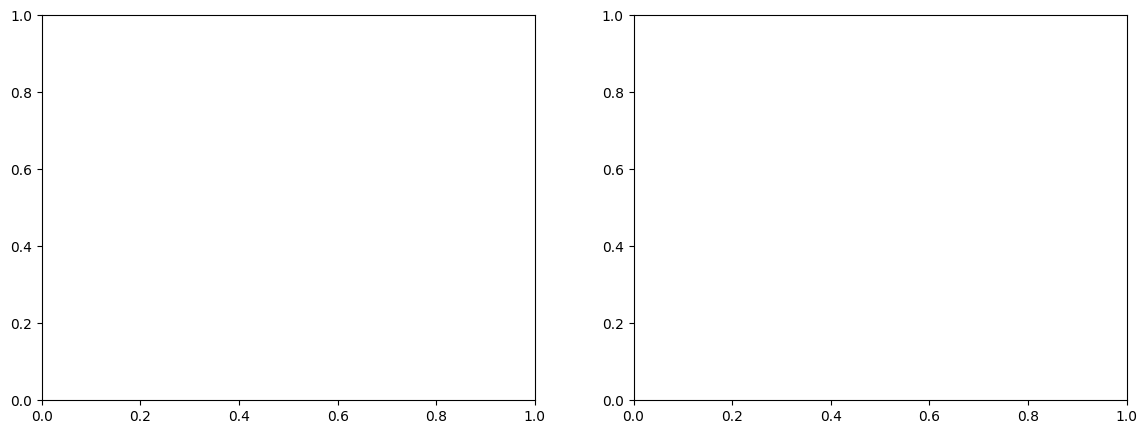

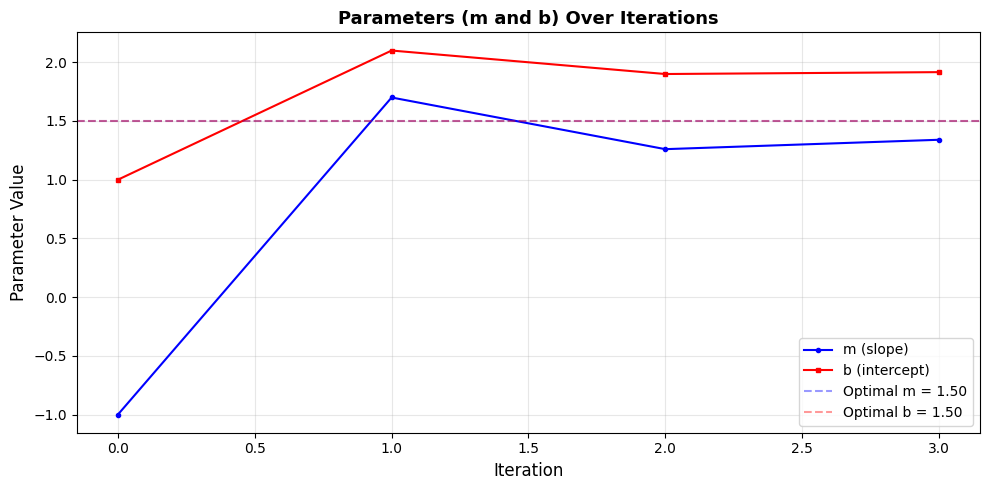

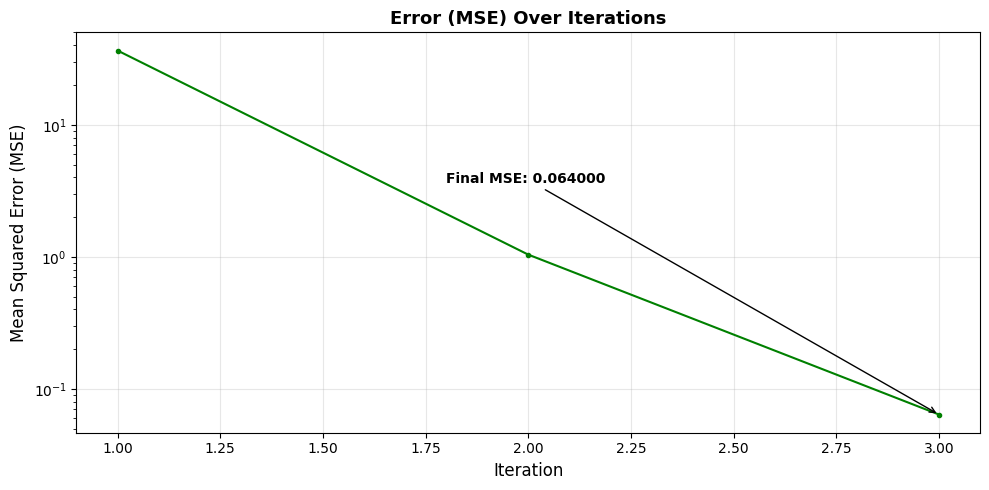

In [24]:
#Initial variables

#Initial data points
X = np.array([1, 3])
Y = np.array([3, 6])
n = len(X)

#Initial parameters
m = -1.0
b = 1.0

#Learning rate
alpha = 0.1 #I don't know how to get the alpha symbol, so I will name it alpha.

#Our loop iteration
iterations = 3

#We need to track the values as we interate
m_history = [m]
b_history = [b]
error_history = []

#let's start
print(f"\nInitial Parameters: m = {m}, b = {b}")
print(f"Learning Rate: {alpha}")
print(f"Data Points: {list(zip(X, Y))}")
print(f"Number of Iterations: {iterations}\n")


for i in range(iterations):
    #Step 1: Compute Predictions
    y_pred = m * X + b  # ŷ = mx + b

    #Step 2: Compute Errors
    errors = Y - y_pred  # eᵢ = yᵢ - ŷᵢ

    #Step 3: Compute MSE (Cost Function)
    mse = (1 / n) * np.sum(errors ** 2)
    error_history.append(mse)

    #Step 4: Compute Gradients
    dJ_dm = (-2 / n) * np.sum(X * errors)  # ∂J/∂m
    dJ_db = (-2 / n) * np.sum(errors)       # ∂J/∂b

    #Step 5: Update Parameters
    m_new = m - alpha * dJ_dm
    b_new = b - alpha * dJ_db

    # Print details of our results for first 5 and last iteration
    if i < 5 or i == iterations - 1:
        print(f"-Iteration {i + 1}")
        print(f"  Predictions:  ŷ = {y_pred}")
        print(f"  Errors:       e = {errors}")
        print(f"  MSE:          J = {mse:.6f}")
        print(f"  Gradients:    ∂J/∂m = {dJ_dm:.6f},  ∂J/∂b = {dJ_db:.6f}")
        print(f"  Updated:      m = {m_new:.6f},  b = {b_new:.6f}")
        print()
        if i == 4 and iterations > 6:
            print(f"  ... (iterations 6 to {iterations - 1} omitted for brevity) ...\n")

    #updates our history variables
    m = m_new
    b = b_new
    m_history.append(m)
    b_history.append(b)

for xi, yi in zip(X, Y):
    y_hat = m * xi + b
    print(f"  x = {xi}: ŷ = {y_hat:.4f} (actual y = {yi})")



def cost_function(params):
    """MSE cost function for SciPy optimizer."""
    m_s, b_s = params
    y_pred_s = m_s * X + b_s
    return (1 / n) * np.sum((Y - y_pred_s) ** 2)

# Use SciPy's minimize to find optimal m and b
result = minimize(cost_function, x0=[-1.0, 1.0], method='BFGS')
print(f"\nSciPy Optimized: m = {result.x[0]:.6f}, b = {result.x[1]:.6f}")
print(f"SciPy Min MSE:   {result.fun:.6f}")
print(f"Converged:       {result.success}")

# let's do Visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Plot 1: m and b over iterations
plt.figure(figsize=(10, 5))
iterations_range = range(len(m_history))
plt.plot(iterations_range, m_history, 'b-o', markersize=3, label='m (slope)', linewidth=1.5)
plt.plot(iterations_range, b_history, 'r-s', markersize=3, label='b (intercept)', linewidth=1.5)
plt.axhline(y=result.x[0], color='blue', linestyle='--', alpha=0.4, label=f'Optimal m = {result.x[0]:.2f}')
plt.axhline(y=result.x[1], color='red', linestyle='--', alpha=0.4, label=f'Optimal b = {result.x[1]:.2f}')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Parameter Value', fontsize=12)
plt.title('Parameters (m and b) Over Iterations', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Plot 2: Error (MSE) Over Iterations
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(error_history) + 1), error_history, 'g-o', markersize=3, linewidth=1.5)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Error (MSE) Over Iterations', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.annotate(f'Final MSE: {error_history[-1]:.6f}',
             xy=(len(error_history), error_history[-1]),
             xytext=(len(error_history) * 0.6, error_history[0] * 0.1),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

